# Feature Selection, Confusion matrix and Decision Region 

## Feature selection
In the previous lectures, we learned how to use hold-out "test" sets and cross-validation to gain appropriate estimates of a model's performance on unseen data. There, the focus was on choosing a good "complexity" parameter, such as the depth of a decision tree. In this lecture, we'll instead show how to use cross-validation to get an estimate of which columns in the data should or should not be included in a model. It's very common in practice that not all columns will be used in the best model, and many, many machine learning reseachers devote their careers to studying the problem of how to intelligently and automatically choose only the most relevant columns for models. In the literature, this problem is usually called *feature selection*. In this lecture, we'll take a quick look at how feature selection can improve model performance. 

For this demonstration, we'll switch from decision trees to logistic regression. Logistic regression is a form of regression modeling well-suited for predicting probabilities and class labels. 

Let's begin by running some familiar blocks of code, in which we load our core libraries, read in the data, split the data, and clean the data. 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
titanic = pd.read_csv('titanic.csv')
titanic

# reading in the dataset

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [3]:
from sklearn.model_selection import train_test_split
np.random.seed(1111)
train, test = train_test_split(titanic, test_size=0.2)



# train,test = train_test_split(titanic, test_size=0.2)
# now have two datasets

In [4]:
from sklearn import preprocessing
def prep_titanic_data(data_df):
    df = data_df.copy()
    le = preprocessing.LabelEncoder()
    df['Sex'] = le.fit_transform(df['Sex'])
    df = df.drop(['Name'], axis=1)
    X = df.drop(['Survived'], axis=1)
    y = df['Survived']
    
    return X, y

# we saw this before 
# what we are doing is cleaning the dataset
# for one dataset:
# use labelEncoder to change Sex labels to 0 and 1
# then dropping column we dont care about
# then splitting each dataset to X and y prediction, df = df.drop(['Feature'], axis=1)



X_train, y_train = prep_titanic_data(train)
X_test, y_test = prep_titanic_data(test)

Deploying logistic regression is easy, and uses exactly the same API as the decision tree classifier. Let's go ahead and use cross-validation to estimate the predictive performance of the model. 

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

LR = LogisticRegression()
cross_val_score(LR, X_train, y_train, cv=5).mean()


# we saw this before we take cross_val_score(LR,X_train,y_train,cv=5).mean()

np.float64(0.7940365597842375)

Is this the best we can do? If you've studied logistic regression before, you may know that using lots of columns doesn't always help -- due to *multicollinearity*, the model's predictive performance can actually suffer. This is actually another aspect of *overfitting*. Adding more columns makes the model more flexible, and we've seen that that is not always beneficial. So, a natural question is whether we can achieve the same (or better?) model performance by using only a subset of the columns. 


It's easy to train a model on a subset of the data. For example: 

In [6]:
cols = ['Pclass', 'Sex', 'Age', 'Siblings/Spouses Aboard','Parents/Children Aboard']
LR = LogisticRegression()
cross_val_score(LR, X_train[cols], y_train, cv=5).mean()

# the difference now is only SOME features are being used... seeing if using less features will impact/improve our score

np.float64(0.8025072420337629)

Interesting! Excluding the last column (Fare) actually improved our CV score slightly. 

## Systematic Feature Selection

Now, let's write a function that will let us do this systematically. Our function will use cross-validation to avoid "peeking" at the test set. 

In [7]:
def check_column_score(cols):
    print('Train with columns ' + str(cols))
    LR = LogisticRegression()
    return cross_val_score(LR, X_train[cols], y_train, cv=5).mean()

We can now check multiple combinations simultaneously. In a real problem, you might check all possible combinations, and in the Penguins data set, for example, this would be possible. In this lecture, however, we'll just compare a few. 

In [10]:
combos = [['Sex', 'Age', 'Fare'], ['Pclass', 'Sex', 'Age'], ['Pclass', 'Parents/Children Aboard'], ['Pclass','Sex','Age','Siblings/Spouses Aboard', 'Parents/Children Aboard'],\
          ['Pclass', 'Sex','Age','Siblings/Spouses Aboard', 'Parents/Children Aboard','Fare']]

# the combo is a list of lists that is then iterated over


for cols in combos:
    x = check_column_score(cols)
    print('CV Score is ' + str(np.round(x, 3)))



# seeing score based hwich features used

Train with columns ['Sex', 'Age', 'Fare']
CV Score is 0.773
Train with columns ['Pclass', 'Sex', 'Age']
CV Score is 0.795
Train with columns ['Pclass', 'Parents/Children Aboard']
CV Score is 0.671
Train with columns ['Pclass', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard']
CV Score is 0.803
Train with columns ['Pclass', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']
CV Score is 0.794


Note that the model that uses all the available columns achieves only the third-highest CV score. The model with the highest CV score uses all columns except for "Fare."

Now let's see how each of these models perform on the test set. 

In [13]:
def test_column_score(cols):
    print('Testing with columns ' + str(cols))
    LR = LogisticRegression()
    LR.fit(X_train[cols], y_train)
    return LR.score(X_test[cols], y_test)

🚂

In [15]:
for cols in combos:
    x = test_column_score(cols)
    print('Test score is ' + str(np.round(x, 3)))



# now doing it on the testing dataset

Testing with columns ['Sex', 'Age', 'Fare']
Test score is 0.82
Testing with columns ['Pclass', 'Sex', 'Age']
Test score is 0.803
Testing with columns ['Pclass', 'Parents/Children Aboard']
Test score is 0.742
Testing with columns ['Pclass', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard']
Test score is 0.831
Testing with columns ['Pclass', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']
Test score is 0.82


Indeed, we achieved a higher prediction score on the test set by ignoring the "Fare" column completely. 

There are a number of sophisticated algorithms for automated feature selection, but we won't go further into this topic in this course. 

## Confusion matrix

The confusion matrix is a simple visualization of the model's predictions against truth. 

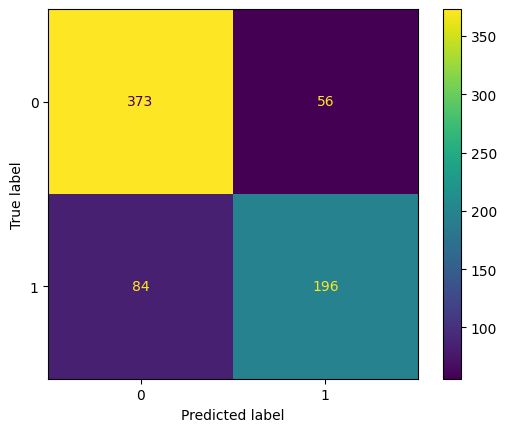

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

LR = LogisticRegression()
LR.fit(X_train, y_train)
y_train_pred = LR.predict(X_train)          # used .predict instead of .score

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)


# now we are using a CONFUSION matrix to visualize the model's prediction results against truth

## Decision Regions

There are many machine learning algorithms, each with very different properties. How can we gain better understanding of how a given algorithm "sees" the data? In this course, we won't study the mathematical structure of our algorithms, but we can in certain cases visualize how they work.


Now we'll take a look at the decision regions of various classifiers. The decision regions are just the parts of data space that the classifier assigns to each label. As we'll see, different classifiers can create very different decision regions, even when they are trained on the same input data.

In [18]:
import pandas as pd 
from matplotlib import pyplot as plt 
import numpy as np

# import pandas as pd
# from matplotlib import pyplot as plt
# import numpy as np

In [19]:
# Grabbing the data
# Grabbing the data
penguins = pd.read_csv('palmer_penguins.csv')
penguins.head()

# grabbing the data

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


### Data Prep

For our purposes today, it's useful to encode the three penguin species with labels 0, 1, and 2. We are going to focus on modeling using only two predictor variables today, the culmen length and depth. We use `df.dropna()` to drop the two penguins for which these variables were not measured.

In [20]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
penguins['label'] = le.fit_transform(penguins['Species']) # turning to - and 1



penguins = penguins.dropna(subset=['Culmen Length (mm)', 'Culmen Depth (mm)'])      # dropping na values
X = penguins[['Culmen Length (mm)', 'Culmen Depth (mm)']]
y = penguins['label']

In [21]:
X

,Culmen Length (mm),Culmen Depth (mm)
0,39.1,18.7
1,39.5,17.4
2,40.3,18.0
4,36.7,19.3
5,39.3,20.6
...,...,...
338,47.2,13.7
340,46.8,14.3
341,50.4,15.7
342,45.2,14.8


In [22]:
y

0      0
1      0
2      0
4      0
5      0
      ..
338    2
340    2
341    2
342    2
343    2
Name: label, Length: 342, dtype: int64

Now let's take a look! Encoding the species as integers 0, 1, 2 makes it easy to create a scatterplot by species, but difficult to add an informative legend. We aren't going to worry about the exact species right now, so we'll just think of them as blue, green, and red. 

[Text(0.5, 0, 'Culmen Length (mm)'), Text(0, 0.5, 'Culmen Depth (mm)')]

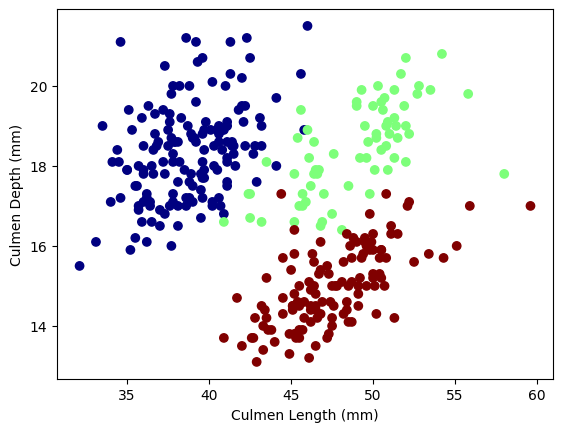

In [23]:
fig, ax = plt.subplots(1)
ax.scatter(X['Culmen Length (mm)'], X['Culmen Depth (mm)'], c=y, cmap='jet')
ax.set(xlabel='Culmen Length (mm)', ylabel='Culmen Depth (mm)')

### Decision Regions By Hand

The core idea of decision regions is to evaluate a given classifier on a large set of points -- often much larger than the actual data. We can then visualize in considerable detail how the classifier "makes decisions." The set of points where the model returns "0", for example, is the decision region for 0. The contours along which different decision regions meet are called **decision boundaries.**

The limitation of this approach is that it works best for classifiers which use only two numerical features. Let's see how to create decision regions by hand! For now, we'll use as our example a decision tree classifier. 

In [24]:
from sklearn import tree
T = tree.DecisionTreeClassifier(max_depth=2)
T.fit(X,y)

#have seen this before yes

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Next, we'll create a 2d grid of `501 x 501` points using `np.meshgrid`: 

In [25]:
x0 = X['Culmen Length (mm)']
x1 = X['Culmen Depth (mm)']
# create grid
grid_x0 = np.linspace(x0.min(), x0.max(), 501)
grid_x1 = np.linspace(x1.min(), x1.max(), 501)
X0, X1 = np.meshgrid(grid_x0, grid_x1)
XX, YY = np.meshgrid(grid_x0, grid_x1)

As is, we can't really use our classifier on these data. We need to reshape `X0` and `X1` so that they "look" more like the columns of a data frame. That is, all the points of `X0` should be in a 1d array. We can do this with `np.ravel()` and the `numpy` *concatenation* operator `np.c_`: 

In [26]:
X0.shape

(501, 501)

In [27]:
# shortcut for reshape
# shortcut for reshape
X0 = X0.ravel()
X0.shape

(251001,)

In [28]:
X1 = X1.ravel()
X1.shape
X01 = pd.DataFrame({'Culmen Length (mm)': X0, 'Culmen Depth (mm)': X1})
X01

,Culmen Length (mm),Culmen Depth (mm)
0,32.100,13.1
1,32.155,13.1
2,32.210,13.1
3,32.265,13.1
4,32.320,13.1
...,...,...
250996,59.380,21.5
250997,59.435,21.5
250998,59.490,21.5
250999,59.545,21.5


Better! Now we can make a prediction using our standard approach: 

In [29]:
p = T.predict(X01)
p.shape

(251001,)

Almost there! The next step toward visualization is to reshape the predictions back into a square grid that we can plot. 

In [30]:
p = p.reshape(XX.shape)

In [31]:
p.shape

(501, 501)

Now we're ready to make the plot! 

[Text(0.5, 0, 'Culmen Length (mm)'), Text(0, 0.5, 'Culmen Depth (mm)')]

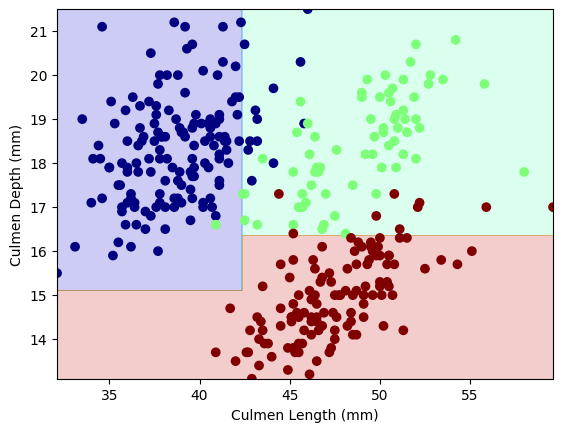

In [32]:
fig, ax = plt.subplots(1)
ax.contourf(XX, YY, p, cmap='jet', alpha=0.2)
ax.scatter(x0, x1, c=y, cmap='jet')
ax.set(xlabel='Culmen Length (mm)', ylabel='Culmen Depth (mm)')

Here's the same code, wrapped up in a function. Feel free to modify this function and use it in your project. 

In [33]:
def plot_regions(c, X, y):
    """
    a simple function to plot decision regions for a classification model c
    if you use this function in your projects, you will need to modify how 
    the prediction works in some important ways, AND you will need to ensure 
    that the plots produced have a legend describing how the colors correspond 
    to species. Additionally, you will need to include a better docstring than 
    this one. =)
    """
        
        
    # for convenience, give names to the two 
    # columns of the data
    x0 = X['Culmen Length (mm)']
    x1 = X['Culmen Depth (mm)']
    
    # create a grid
    grid_x = np.linspace(x0.min(),x0.max(),501)
    grid_y = np.linspace(x1.min(),x1.max(),501)
    xx, yy = np.meshgrid(grid_x, grid_y)
    
    # extract model predictions, using the 
    # np.c_ attribute to join together the 
    # two parts of the grid. 
    # array.ravel() converts an multidimensional
    # array into a 1d array, and we use array.reshape()
    # to turn the resulting predictions p 
    # back into 2d
    
    XX = xx.ravel()
    YY = yy.ravel()
    XY = pd.DataFrame({
        "Culmen Length (mm)" : XX,
        "Culmen Depth (mm)"  : YY
    })
    
    p = c.predict(XY)
    p = p.reshape(xx.shape)
    
    # create the plot
    fig, ax = plt.subplots(1)
    
    # use contour plot to visualize the predictions
    ax.contourf(xx, yy, p, cmap = "jet", alpha = 0.2, vmin = 0, vmax = 2)
    
    # plot the data
    ax.scatter(x0, x1, c = y, cmap = "jet", vmin = 0, vmax = 2)
    
    ax.set(xlabel = "Culmen Length (mm)", 
           ylabel = "Culmen Depth (mm)")

### Examples

#### Decision Trees

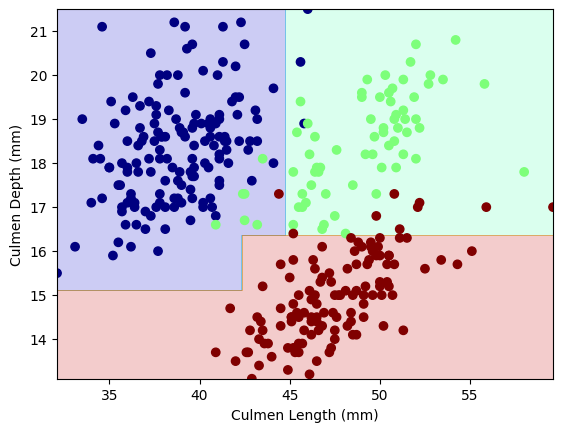

In [31]:
T = tree.DecisionTreeClassifier(max_depth=3)
T.fit(X, y)
plot_regions(T, X, y)

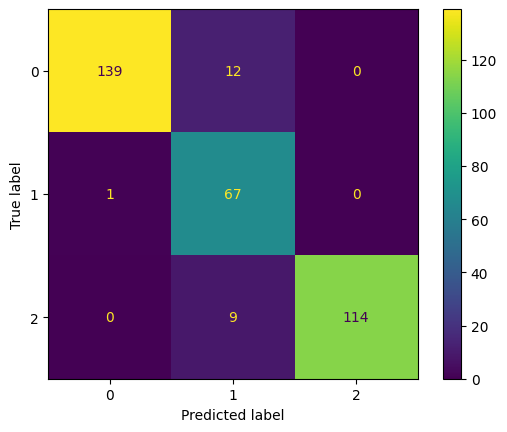

In [34]:
# confusion matrix
y_pred = T.predict(X)
ConfusionMatrixDisplay.from_predictions(y, y_pred)

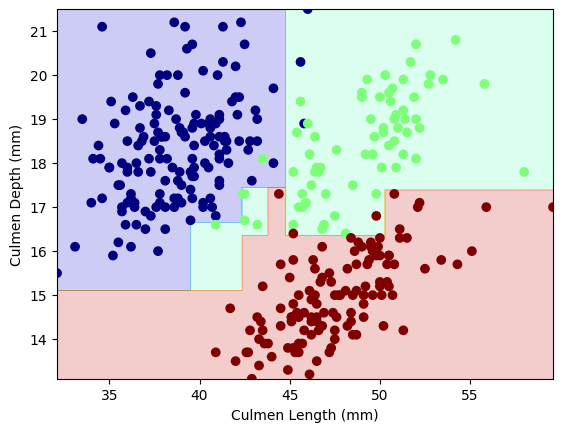

In [33]:
T = tree.DecisionTreeClassifier(max_depth=5)
T.fit(X, y)
plot_regions(T, X, y)

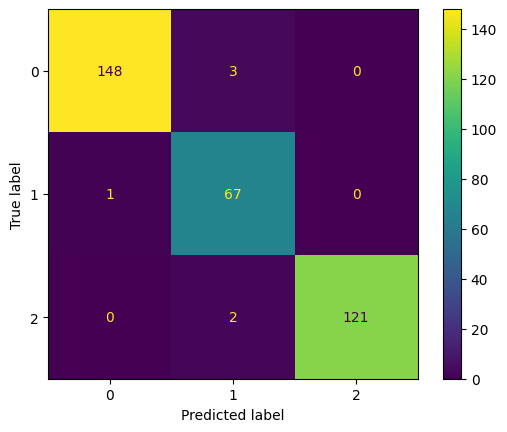

In [34]:
y_pred = T.predict(X)
ConfusionMatrixDisplay.from_predictions(y, y_pred)

#### Random Forests

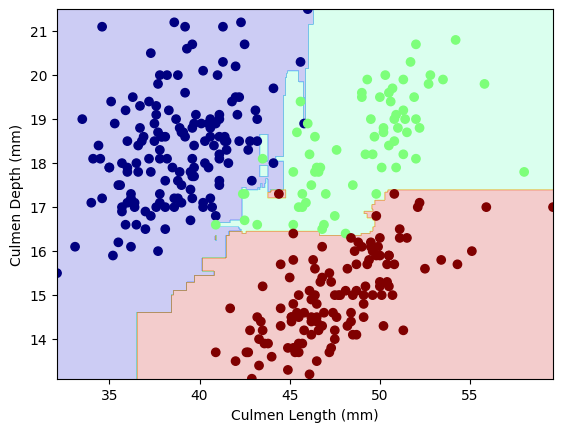

In [36]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier()
RF.fit(X, y)
plot_regions(RF, X, y)

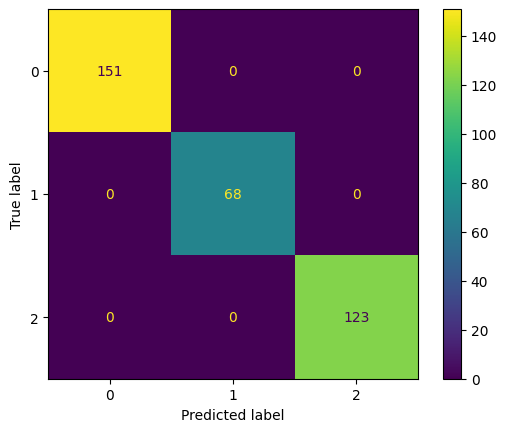

In [37]:
# confusion matrix
y_pred = RF.predict(X)
ConfusionMatrixDisplay.from_predictions(y, y_pred)

#### Logistic Regression

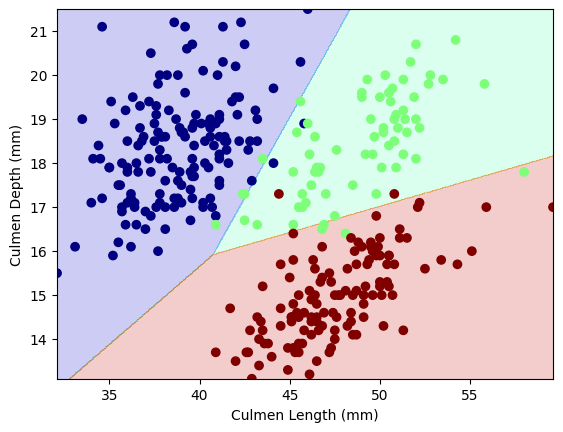

In [38]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(X, y)
plot_regions(LR, X, y)

#### Support Vector Machines

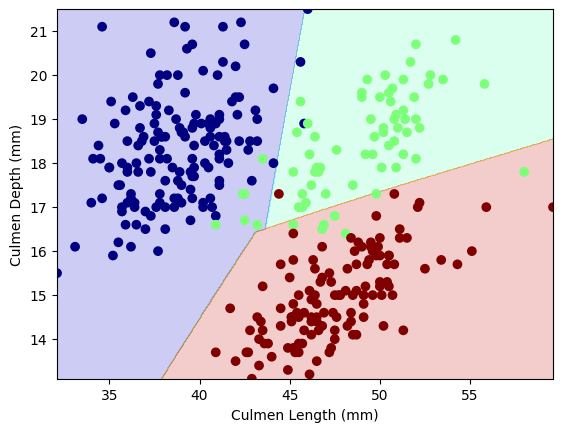

In [40]:
from sklearn import svm
SVM = svm.SVC()
SVM.fit(X, y)
plot_regions(SVM, X, y)